# 04. Causal Forests

Causal forests are one of the most important tree-based methods for estimating heterogeneous treatment effects. They extend the random forest idea from prediction to causal effect estimation: instead of averaging outcomes in many tree leaves, we average treatment-control contrasts in many locally similar leaves.

This notebook builds an educational causal forest from scratch. It is not a replacement for production libraries such as `grf`, EconML, or causalml, but it exposes the mechanics: adaptive neighborhoods, honest splitting, leaf-level treatment effects, forest averaging, and validation by ranked groups.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain why a regression forest is not automatically a causal forest.
- Describe causal trees, honesty, adaptive neighborhoods, and forest weights.
- Build a simplified honest causal forest for a randomized experiment.
- Compare a single causal tree, transformed-outcome random forest, T-learner, and honest causal forest.
- Interpret forest predictions, tree-to-tree stability, and feature importance carefully.
- Translate a causal forest score into decile validation and treatment targeting curves.

In [1]:
import warnings
from collections import defaultdict

import graphviz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    graph = graphviz.Digraph(format="svg")
    graph.attr(rankdir=rankdir, bgcolor="white", pad="0.2")
    graph.attr("node", shape="box", style="rounded,filled", color="#334155", fontname="Helvetica")
    graph.attr("edge", color="#475569", arrowsize="0.8")

    node_colors = node_colors or {}
    nodes = sorted({node for edge in edges for node in edge[:2]})
    for node in nodes:
        graph.node(node, fillcolor=node_colors.get(node, "#eef2ff"))

    for edge in edges:
        if len(edge) == 2:
            graph.edge(edge[0], edge[1])
        else:
            graph.edge(edge[0], edge[1], label=edge[2])

    if title:
        graph.attr(label=title, labelloc="t", fontsize="18", fontname="Helvetica-Bold")
    return graph


def simulate_success_playbook_experiment(n=9_000, seed=5404):
    rng = np.random.default_rng(seed)

    risk_score = rng.beta(2.2, 2.7, n)
    engagement_score = rng.beta(2.5, 2.0, n)
    log_account_value = rng.normal(4.25, 0.60, n)
    account_value = np.exp(log_account_value)
    tenure_months = rng.gamma(2.1, 10.0, n)
    enterprise_plan = rng.binomial(1, sigmoid(-0.30 + 0.65 * (log_account_value - 4.25) + 0.45 * risk_score), n)
    integration_count = rng.poisson(np.clip(1.2 + 4.0 * engagement_score + 1.2 * enterprise_plan, 0.2, None))
    support_tickets = rng.poisson(np.clip(0.5 + 3.2 * risk_score - 0.8 * engagement_score + 0.5 * enterprise_plan, 0.1, None))

    treatment = rng.binomial(1, 0.5, n)

    mu0 = (
        80
        + 0.12 * account_value
        + 9.0 * engagement_score
        - 12.0 * risk_score
        + 4.0 * enterprise_plan
        + 0.08 * tenure_months
        + 1.3 * integration_count
        - 1.7 * support_tickets
        + 2.0 * np.sin(2 * engagement_score)
    )

    true_cate = (
        -3.0
        + 18.0 * risk_score * (1 - engagement_score)
        + 4.0 * enterprise_plan
        + 3.0 * (support_tickets >= 4).astype(float)
        - 4.0 * (engagement_score > 0.82).astype(float)
        + 2.0 * np.log1p(integration_count)
        - 2.0 * (tenure_months < 5).astype(float)
    )

    y0 = mu0 + rng.normal(0, 6.5, n)
    y1 = y0 + true_cate
    outcome = np.where(treatment == 1, y1, y0)

    return pd.DataFrame(
        {
            "account_id": np.arange(1, n + 1),
            "risk_score": risk_score,
            "engagement_score": engagement_score,
            "log_account_value": log_account_value,
            "account_value": account_value,
            "tenure_months": tenure_months,
            "enterprise_plan": enterprise_plan,
            "integration_count": integration_count,
            "support_tickets": support_tickets,
            "treatment": treatment,
            "outcome": outcome,
            "mu0": mu0,
            "true_cate": true_cate,
        }
    )


def difference_in_means(frame, outcome="outcome", treatment="treatment"):
    treated = frame.loc[frame[treatment] == 1, outcome]
    control = frame.loc[frame[treatment] == 0, outcome]
    if len(treated) < 2 or len(control) < 2:
        return np.nan, np.nan
    estimate = treated.mean() - control.mean()
    se = np.sqrt(treated.var(ddof=1) / len(treated) + control.var(ddof=1) / len(control))
    return estimate, se


def transformed_outcome(frame, treatment_prob=0.5):
    return frame["outcome"] * (frame["treatment"] - treatment_prob) / (treatment_prob * (1 - treatment_prob))


def top_fraction_mask(frame, score_col, fraction=0.20, largest=True):
    n_select = max(1, int(np.floor(fraction * len(frame))))
    selected_index = frame[score_col].sort_values(ascending=not largest).head(n_select).index
    mask = pd.Series(False, index=frame.index)
    mask.loc[selected_index] = True
    return mask


def fit_honest_tree(sample, feature_cols, seed=1, max_depth=4, min_samples_leaf=120, treatment_prob=0.5):
    discovery, estimation = train_test_split(
        sample,
        test_size=0.50,
        random_state=seed,
        stratify=sample["treatment"],
    )

    tree = DecisionTreeRegressor(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=seed,
    )
    tree.fit(discovery[feature_cols], transformed_outcome(discovery, treatment_prob=treatment_prob))

    estimation = estimation.copy()
    estimation["leaf_id"] = tree.apply(estimation[feature_cols])

    leaf_effects = {}
    leaf_se = {}
    leaf_counts = {}
    leaf_indices = {}
    for leaf_id, leaf_frame in estimation.groupby("leaf_id"):
        effect, se = difference_in_means(leaf_frame)
        leaf_effects[leaf_id] = effect
        leaf_se[leaf_id] = se
        leaf_counts[leaf_id] = len(leaf_frame)
        leaf_indices[leaf_id] = leaf_frame.index.to_numpy()

    global_effect, _ = difference_in_means(estimation)
    return {
        "tree": tree,
        "leaf_effects": leaf_effects,
        "leaf_se": leaf_se,
        "leaf_counts": leaf_counts,
        "leaf_indices": leaf_indices,
        "discovery_index": discovery.index.to_numpy(),
        "estimation_index": estimation.index.to_numpy(),
        "global_effect": global_effect,
    }


def predict_honest_tree(tree_bundle, X):
    leaves = tree_bundle["tree"].apply(X)
    fallback = tree_bundle["global_effect"]
    predictions = []
    for leaf in leaves:
        value = tree_bundle["leaf_effects"].get(leaf, fallback)
        if pd.isna(value):
            value = fallback
        predictions.append(value)
    return np.asarray(predictions)


def honest_leaf_table(tree_bundle, estimation_frame):
    rows = []
    for leaf_id, effect in tree_bundle["leaf_effects"].items():
        idx = tree_bundle["leaf_indices"][leaf_id]
        leaf_frame = estimation_frame.loc[idx]
        rows.append(
            {
                "leaf_id": leaf_id,
                "n": len(leaf_frame),
                "treatment_share": leaf_frame["treatment"].mean(),
                "estimated_effect": effect,
                "std_error": tree_bundle["leaf_se"].get(leaf_id, np.nan),
                "ci_low": effect - 1.96 * tree_bundle["leaf_se"].get(leaf_id, np.nan),
                "ci_high": effect + 1.96 * tree_bundle["leaf_se"].get(leaf_id, np.nan),
                "true_cate_mean": leaf_frame["true_cate"].mean(),
                "mean_risk": leaf_frame["risk_score"].mean(),
                "mean_engagement": leaf_frame["engagement_score"].mean(),
            }
        )
    return pd.DataFrame(rows).sort_values("estimated_effect").reset_index(drop=True)


def fit_honest_forest(train, feature_cols, n_trees=90, sample_fraction=0.65, seed=100, max_depth=5, min_samples_leaf=80):
    rng = np.random.default_rng(seed)
    bundles = []
    n_sample = int(sample_fraction * len(train))

    for tree_id in range(n_trees):
        sample_index = rng.choice(train.index.to_numpy(), size=n_sample, replace=False)
        sample = train.loc[sample_index]
        bundle = fit_honest_tree(
            sample,
            feature_cols,
            seed=seed + tree_id,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
        )
        bundles.append(bundle)

    split_importance = np.vstack([bundle["tree"].feature_importances_ for bundle in bundles]).mean(axis=0)
    return {"bundles": bundles, "feature_cols": feature_cols, "split_importance": split_importance}


def predict_honest_forest(forest, X):
    tree_predictions = np.column_stack([predict_honest_tree(bundle, X) for bundle in forest["bundles"]])
    return pd.DataFrame(
        {
            "cate_hat": np.nanmean(tree_predictions, axis=1),
            "tree_sd": np.nanstd(tree_predictions, axis=1, ddof=1),
            "tree_q10": np.nanquantile(tree_predictions, 0.10, axis=1),
            "tree_q90": np.nanquantile(tree_predictions, 0.90, axis=1),
        },
        index=X.index,
    )


def forest_neighbor_weights(forest, x_row):
    weights = defaultdict(float)
    n_trees = len(forest["bundles"])
    feature_cols = forest["feature_cols"]

    for bundle in forest["bundles"]:
        leaf_id = bundle["tree"].apply(x_row[feature_cols])[0]
        neighbor_index = bundle["leaf_indices"].get(leaf_id, np.array([]))
        if len(neighbor_index) == 0:
            continue
        per_neighbor_weight = 1 / (n_trees * len(neighbor_index))
        for idx in neighbor_index:
            weights[idx] += per_neighbor_weight

    return pd.Series(weights).sort_values(ascending=False)


def model_metrics(frame, score_col, label, contact_fraction=0.20):
    selected = top_fraction_mask(frame, score_col, fraction=contact_fraction)
    targeted = frame.loc[selected]
    return {
        "model": label,
        "cate_rmse": np.sqrt(mean_squared_error(frame["true_cate"], frame[score_col])),
        "cate_correlation": np.corrcoef(frame["true_cate"], frame[score_col])[0, 1],
        "mean_predicted_cate": frame[score_col].mean(),
        "true_cate_top20": targeted["true_cate"].mean(),
        "negative_cate_share_top20": (targeted["true_cate"] < 0).mean(),
    }


def decile_validation_table(frame, score_col):
    work = frame.sort_values(score_col, ascending=False).reset_index(drop=True).copy()
    work["score_decile"] = pd.qcut(
        np.arange(len(work)),
        q=10,
        labels=[f"D{i} highest" if i == 1 else f"D{i}" for i in range(1, 11)],
    )

    rows = []
    for decile, group in work.groupby("score_decile", observed=True):
        effect, se = difference_in_means(group)
        rows.append(
            {
                "decile": str(decile),
                "n": len(group),
                "treatment_share": group["treatment"].mean(),
                "observed_lift": effect,
                "ci_low": effect - 1.96 * se,
                "ci_high": effect + 1.96 * se,
                "predicted_cate_mean": group[score_col].mean(),
                "true_cate_mean": group["true_cate"].mean(),
                "tree_sd_mean": group["forest_tree_sd"].mean() if "forest_tree_sd" in group else np.nan,
            }
        )
    return pd.DataFrame(rows)

## 1. Regression Forests Versus Causal Forests

A random forest for prediction estimates an outcome surface:

$$
\hat{m}(x) \approx E[Y \mid X=x]
$$

A causal forest estimates a treatment-effect surface:

$$
\hat{\tau}(x) \approx E[Y(1)-Y(0) \mid X=x]
$$

Those are different targets. A feature that strongly predicts revenue may not modify the treatment effect. A feature that barely predicts revenue may be crucial for treatment responsiveness.

Breiman (2001) introduced random forests as ensembles of randomized trees for prediction. Athey and Imbens (2016) adapted tree partitioning to heterogeneous causal effects using honest estimation. Wager and Athey (2018) developed causal forests for heterogeneous treatment-effect estimation. Athey, Tibshirani, and Wager (2019) generalized this idea by viewing forests as adaptive local weighting schemes for solving local moment equations.

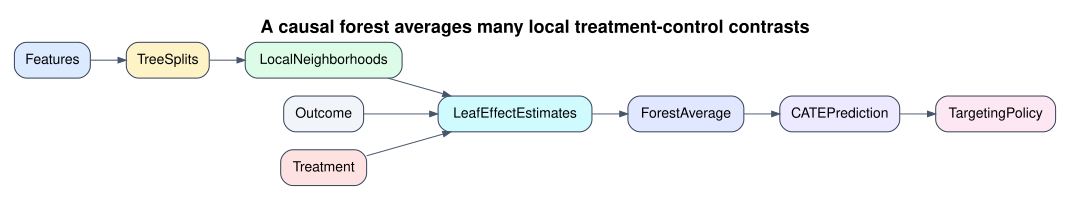

In [3]:
make_dag(
    edges=[
        ("Features", "TreeSplits"),
        ("TreeSplits", "LocalNeighborhoods"),
        ("Treatment", "LeafEffectEstimates"),
        ("Outcome", "LeafEffectEstimates"),
        ("LocalNeighborhoods", "LeafEffectEstimates"),
        ("LeafEffectEstimates", "ForestAverage"),
        ("ForestAverage", "CATEPrediction"),
        ("CATEPrediction", "TargetingPolicy"),
    ],
    title="A causal forest averages many local treatment-control contrasts",
    node_colors={
        "Features": "#dbeafe",
        "TreeSplits": "#fef3c7",
        "LocalNeighborhoods": "#dcfce7",
        "Treatment": "#fee2e2",
        "Outcome": "#f1f5f9",
        "LeafEffectEstimates": "#cffafe",
        "ForestAverage": "#e0e7ff",
        "CATEPrediction": "#ede9fe",
        "TargetingPolicy": "#fce7f3",
    },
)

The key forest intuition is adaptive nearest neighbors. For a target account with features $x$, each tree places that account into a leaf. The estimation-sample accounts in the same leaf become local neighbors. The forest prediction averages treatment-effect estimates across many such neighborhoods.

## 2. Honesty

A causal tree can overstate heterogeneity if the same data are used both to find splits and to estimate leaf effects. Honesty addresses this by splitting the sample into two roles:

- Discovery sample: choose the tree structure.
- Estimation sample: estimate treatment effects within the discovered leaves.

This separation is important because treatment effects are never observed at the individual level. If we repeatedly search for subgroups and estimate them on the same data, we can mistake noise for heterogeneity.

In this educational implementation, each tree will:

1. Draw a random subsample of the training data.
2. Split that subsample into discovery and estimation halves.
3. Fit a tree on a transformed outcome in the discovery half.
4. Estimate treatment-control differences in the estimation half leaves.
5. Predict a new account by dropping it through the tree and using the effect estimate in its leaf.

## 3. Running Example: Success Playbook Experiment

A SaaS company tests a high-touch success playbook. The playbook includes success-manager outreach, workflow review, and a tailored adoption plan. The outcome is next-quarter account value.

The experiment is randomized with treatment probability 0.5. That lets us focus on the causal forest mechanics without simultaneously solving confounding. Later, in production observational settings, causal forests are often combined with nuisance models for outcome and propensity adjustment.

In [4]:
df = simulate_success_playbook_experiment()

feature_cols = [
    "risk_score",
    "engagement_score",
    "log_account_value",
    "tenure_months",
    "enterprise_plan",
    "integration_count",
    "support_tickets",
]

summary = pd.DataFrame(
    {
        "quantity": [
            "Accounts",
            "Treatment share",
            "Outcome mean",
            "True ATE",
            "True CATE standard deviation",
            "Share with negative true CATE",
        ],
        "value": [
            len(df),
            df["treatment"].mean(),
            df["outcome"].mean(),
            df["true_cate"].mean(),
            df["true_cate"].std(),
            (df["true_cate"] < 0).mean(),
        ],
    }
)

display(summary.round(3))
display(df.head())

,quantity,value
0,Accounts,9000.000
1,Treatment share,0.497
2,Outcome mean,99.703
3,True ATE,5.203
4,True CATE standard deviation,4.212
5,Share with negative true CATE,0.087


,account_id,risk_score,engagement_score,log_account_value,account_value,tenure_months,enterprise_plan,integration_count,support_tickets,treatment,outcome,mu0,true_cate
0,1,0.350,0.391,3.914,50.109,44.304,1,4,0,0,99.505,99.486,8.057
1,2,0.717,0.395,4.886,132.472,11.013,1,1,6,1,92.603,88.245,13.198
2,3,0.259,0.200,5.742,311.680,58.479,1,3,3,0,114.522,124.341,7.509
3,4,0.790,0.849,5.076,160.122,19.194,0,6,4,0,100.677,101.893,2.044
4,5,0.299,0.322,4.510,90.959,32.640,1,4,2,0,100.047,99.845,7.863


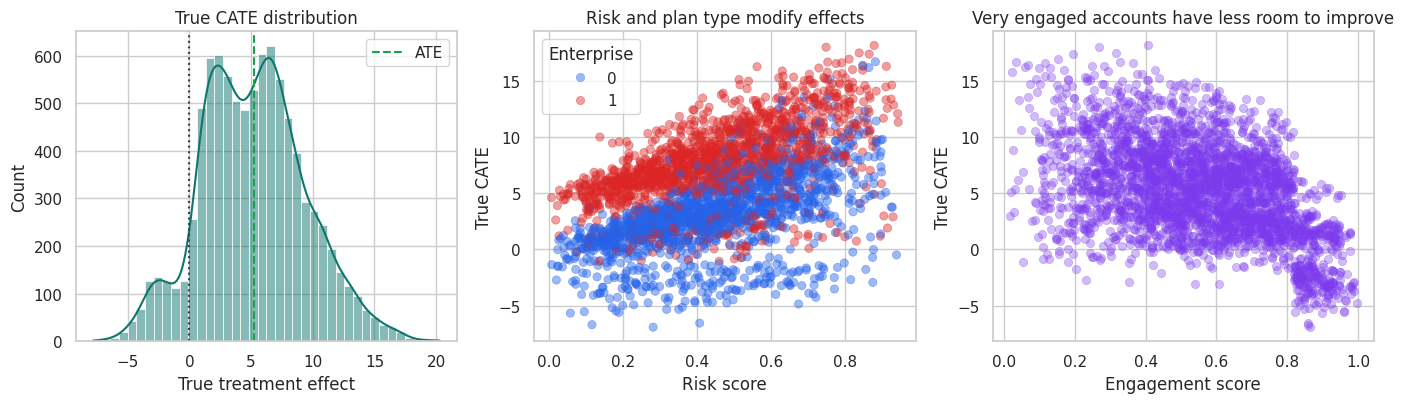

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

sns.histplot(df["true_cate"], bins=40, kde=True, color="#0f766e", ax=axes[0])
axes[0].axvline(df["true_cate"].mean(), color="#16a34a", linestyle="--", label="ATE")
axes[0].axvline(0, color="#334155", linestyle=":")
axes[0].set_title("True CATE distribution")
axes[0].set_xlabel("True treatment effect")
axes[0].legend()

sample_plot = df.sample(3000, random_state=12)
sns.scatterplot(
    data=sample_plot,
    x="risk_score",
    y="true_cate",
    hue="enterprise_plan",
    alpha=0.45,
    edgecolor=None,
    palette=["#2563eb", "#dc2626"],
    ax=axes[1],
)
axes[1].set_title("Risk and plan type modify effects")
axes[1].set_xlabel("Risk score")
axes[1].set_ylabel("True CATE")
axes[1].legend(title="Enterprise")

sns.scatterplot(
    data=sample_plot,
    x="engagement_score",
    y="true_cate",
    alpha=0.35,
    edgecolor=None,
    color="#7c3aed",
    ax=axes[2],
)
axes[2].set_title("Very engaged accounts have less room to improve")
axes[2].set_xlabel("Engagement score")
axes[2].set_ylabel("True CATE")

plt.tight_layout()
plt.show()

The treatment effect is nonlinear. High-risk, low-engagement accounts tend to benefit most. Very engaged accounts have less room to improve and can have low or negative incremental value.

## 4. Baseline ATE and Train-Test Split

The average effect is easy to estimate because treatment is randomized. The harder task is estimating how the effect changes across accounts.

In [6]:
ate_hat, ate_se = difference_in_means(df)
ate_table = pd.DataFrame(
    {
        "quantity": ["Estimated ATE", "95% CI lower", "95% CI upper", "True ATE"],
        "value": [ate_hat, ate_hat - 1.96 * ate_se, ate_hat + 1.96 * ate_se, df["true_cate"].mean()],
    }
)

display(ate_table.round(3))

train_df, test_df = train_test_split(df, test_size=0.35, random_state=41, stratify=df["treatment"])

split_table = pd.DataFrame(
    {
        "sample": ["Train", "Test"],
        "n": [len(train_df), len(test_df)],
        "treatment_share": [train_df["treatment"].mean(), test_df["treatment"].mean()],
        "true_ate": [train_df["true_cate"].mean(), test_df["true_cate"].mean()],
    }
)

display(split_table.round(3))

,quantity,value
0,Estimated ATE,5.385
1,95% CI lower,4.903
2,95% CI upper,5.866
3,True ATE,5.203


,sample,n,treatment_share,true_ate
0,Train,5850,0.497,5.212
1,Test,3150,0.497,5.186


## 5. A Single Honest Causal Tree

For randomized treatment with probability $e=0.5$, a transformed outcome is:

$$
Y_i^* = Y_i\frac{W_i-e}{e(1-e)}
$$

Its conditional expectation equals the CATE:

$$
E[Y_i^* \mid X_i=x] = \tau(x)
$$

We use this transformed outcome only to choose splits in the discovery sample. The final leaf effects are estimated with treatment-control differences in the separate estimation sample.

|--- tenure_months <= 7.59
|   |--- tenure_months <= 5.42
|   |   |--- value: [-4.19]
|   |--- tenure_months >  5.42
|   |   |--- value: [-46.88]
|--- tenure_months >  7.59
|   |--- tenure_months <= 24.62
|   |   |--- tenure_months <= 18.02
|   |   |   |--- tenure_months <= 15.99
|   |   |   |   |--- value: [10.32]
|   |   |   |--- tenure_months >  15.99
|   |   |   |   |--- value: [-19.62]
|   |   |--- tenure_months >  18.02
|   |   |   |--- tenure_months <= 20.29
|   |   |   |   |--- value: [70.82]
|   |   |   |--- tenure_months >  20.29
|   |   |   |   |--- value: [17.52]
|   |--- tenure_months >  24.62
|   |   |--- log_account_value <= 4.75
|   |   |   |--- log_account_value <= 4.17
|   |   |   |   |--- value: [-13.75]
|   |   |   |--- log_account_value >  4.17
|   |   |   |   |--- value: [28.73]
|   |   |--- log_account_value >  4.75
|   |   |   |--- value: [-30.82]



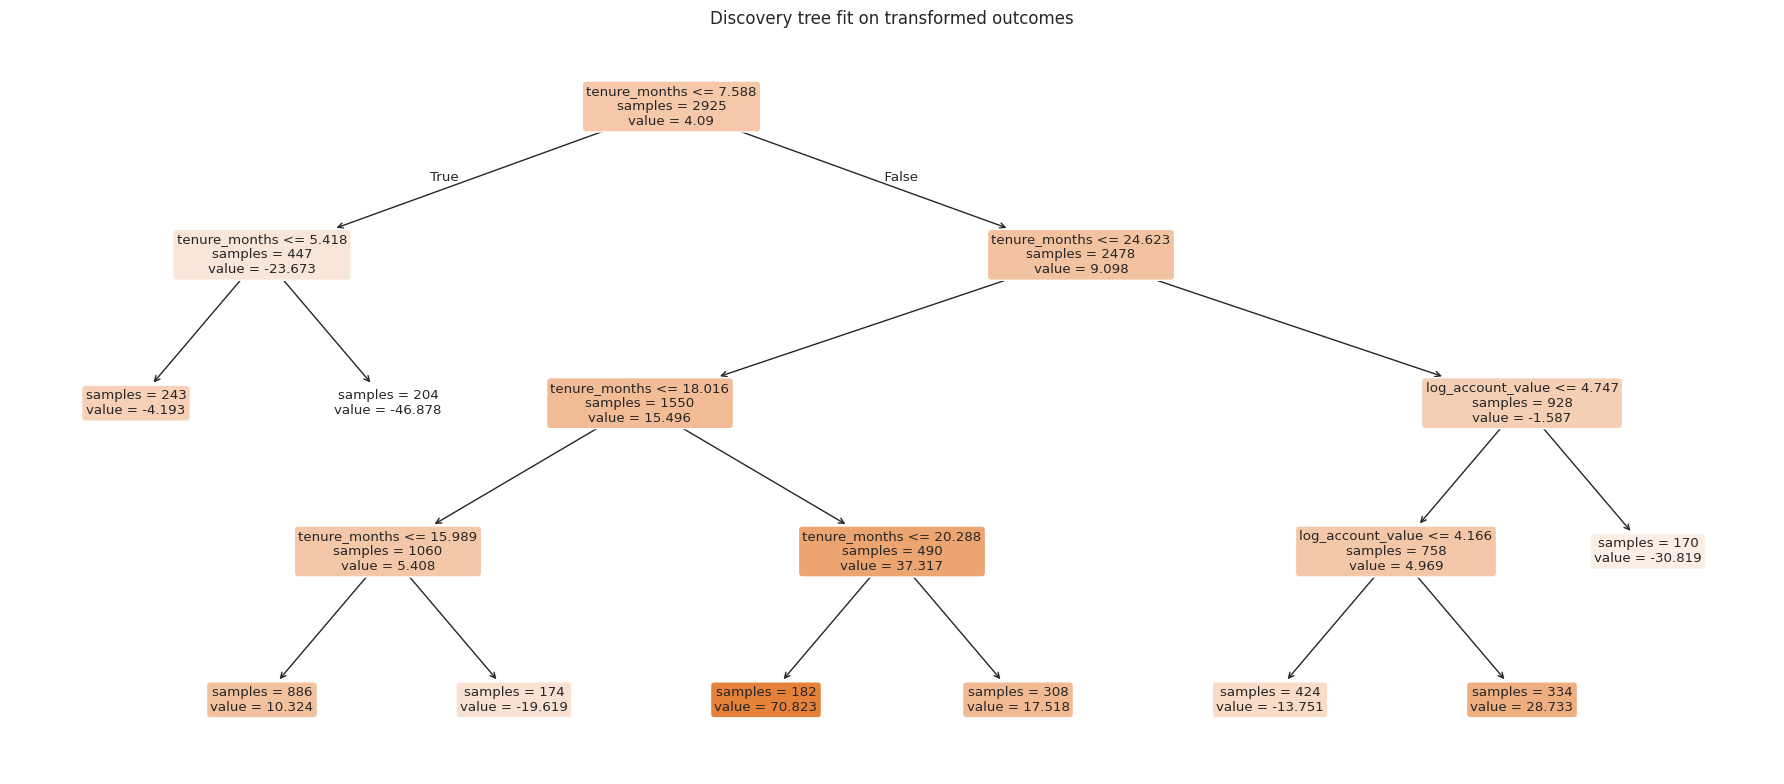

In [7]:
single_tree = fit_honest_tree(
    train_df,
    feature_cols,
    seed=705,
    max_depth=4,
    min_samples_leaf=160,
)

print(export_text(single_tree["tree"], feature_names=feature_cols, decimals=2))

fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(
    single_tree["tree"],
    feature_names=feature_cols,
    filled=True,
    rounded=True,
    impurity=False,
    ax=ax,
)
ax.set_title("Discovery tree fit on transformed outcomes")
plt.tight_layout()
plt.show()

,leaf_id,n,treatment_share,estimated_effect,std_error,ci_low,ci_high,true_cate_mean,mean_risk,mean_engagement
0,2,252,0.484,2.650,1.430,-0.153,5.453,3.119,0.417,0.539
1,11,338,0.497,4.755,1.193,2.416,7.094,5.773,0.469,0.554
2,16,182,0.549,4.850,1.743,1.433,8.266,5.954,0.444,0.543
3,3,179,0.508,5.081,1.727,1.696,8.466,5.466,0.439,0.562
4,14,415,0.501,5.884,0.896,4.127,7.641,4.799,0.457,0.564
5,15,325,0.468,6.178,1.009,4.200,8.157,5.440,0.431,0.552
6,8,182,0.478,6.357,1.642,3.139,9.576,5.368,0.457,0.557
7,7,872,0.495,7.462,0.777,5.940,8.985,5.340,0.442,0.558
8,10,180,0.528,7.575,1.818,4.011,11.139,5.435,0.419,0.500


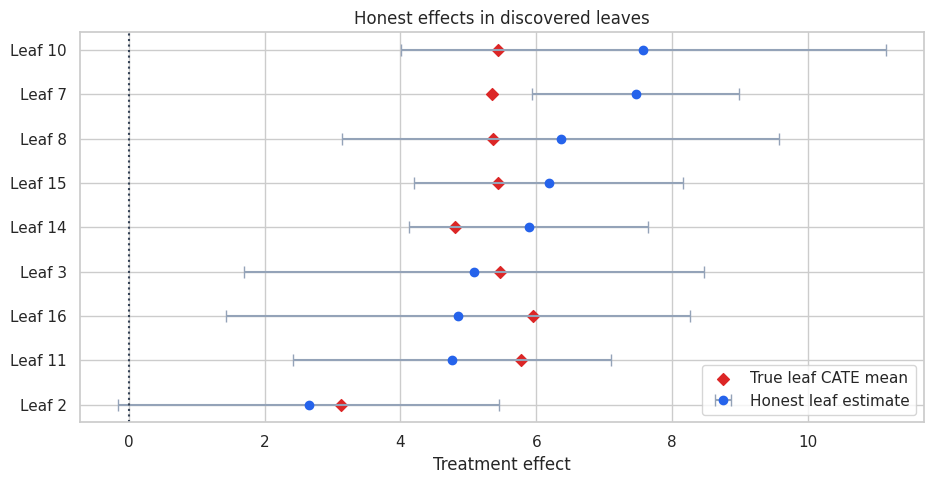

In [8]:
estimation_frame = train_df.loc[single_tree["estimation_index"]].copy()
leaf_table = honest_leaf_table(single_tree, estimation_frame)

display(leaf_table.round(3))

fig, ax = plt.subplots(figsize=(9.5, 5))
y = np.arange(len(leaf_table))
ax.errorbar(
    leaf_table["estimated_effect"],
    y,
    xerr=np.vstack([
        leaf_table["estimated_effect"] - leaf_table["ci_low"],
        leaf_table["ci_high"] - leaf_table["estimated_effect"],
    ]),
    fmt="o",
    color="#2563eb",
    ecolor="#94a3b8",
    capsize=4,
    label="Honest leaf estimate",
)
ax.scatter(leaf_table["true_cate_mean"], y, color="#dc2626", marker="D", label="True leaf CATE mean")
ax.axvline(0, color="#334155", linestyle=":")
ax.set_yticks(y)
ax.set_yticklabels([f"Leaf {leaf}" for leaf in leaf_table["leaf_id"]])
ax.set_xlabel("Treatment effect")
ax.set_title("Honest effects in discovered leaves")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

A single tree is interpretable, but it is unstable. Small changes in the sample can change the splits. A forest reduces this instability by averaging many randomized honest trees.

## 6. Honest Causal Forest

The forest below repeats the honest-tree procedure many times. Each tree sees a random subsample, chooses splits using a discovery half, and estimates leaf effects using an estimation half.

For a target account $x$, tree $b$ gives a local estimate $\hat{\tau}_b(x)$. The forest prediction averages over trees:

$$
\hat{\tau}_{forest}(x) = \frac{1}{B}\sum_{b=1}^B \hat{\tau}_b(x)
$$

This is an educational implementation. Production causal forests use more sophisticated splitting criteria, nuisance adjustments, variance estimation, and optimized code.

In [9]:
honest_forest = fit_honest_forest(
    train_df,
    feature_cols,
    n_trees=90,
    sample_fraction=0.65,
    seed=900,
    max_depth=5,
    min_samples_leaf=80,
)

forest_predictions = predict_honest_forest(honest_forest, test_df[feature_cols])

test_scored = test_df.copy()
test_scored["cate_honest_tree"] = predict_honest_tree(single_tree, test_scored[feature_cols])
test_scored["cate_honest_forest"] = forest_predictions["cate_hat"]
test_scored["forest_tree_sd"] = forest_predictions["tree_sd"]
test_scored["forest_tree_q10"] = forest_predictions["tree_q10"]
test_scored["forest_tree_q90"] = forest_predictions["tree_q90"]

display(
    test_scored[
        [
            "account_id",
            "risk_score",
            "engagement_score",
            "enterprise_plan",
            "true_cate",
            "cate_honest_forest",
            "forest_tree_sd",
            "forest_tree_q10",
            "forest_tree_q90",
        ]
    ].head(10).round(3)
)

,account_id,risk_score,engagement_score,enterprise_plan,true_cate,cate_honest_forest,forest_tree_sd,forest_tree_q10,forest_tree_q90
6979,6980,0.110,0.664,1,4.882,4.080,2.359,0.783,6.970
5929,5930,0.572,0.200,0,8.007,5.985,2.193,3.248,8.523
1820,1821,0.880,0.476,0,9.690,7.880,2.896,4.442,11.701
2376,2377,0.726,0.320,0,7.273,6.762,3.337,2.539,11.347
5836,5837,0.534,0.827,1,2.552,4.899,2.098,2.151,7.518
848,849,0.148,0.657,1,4.685,5.254,2.645,1.671,8.595
1141,1142,0.167,0.811,1,4.341,4.279,2.629,0.782,6.898
3155,3156,0.526,0.816,1,6.903,5.166,2.003,2.527,7.445
8237,8238,0.227,0.640,1,2.669,4.889,2.689,1.846,8.455
3395,3396,0.321,0.456,1,6.915,6.233,2.259,3.083,9.048


The tree-to-tree standard deviation is a stability diagnostic, not a formal standard error. Trees are correlated because they are trained on overlapping data, so treating this as an independent sampling standard error would be too optimistic. Still, high tree-to-tree disagreement is useful for flagging uncertain predictions.

## 7. Forests as Adaptive Neighborhoods

Generalized random forests can be understood as local weighting methods. For a target account, each tree defines a local neighborhood: the estimation-sample accounts that land in the same leaf. The forest averages across many such neighborhoods.

The next cell picks one high predicted-CATE account and shows the training accounts that most often share leaves with it.

In [10]:
target_index = test_scored.sort_values("cate_honest_forest", ascending=False).index[0]
target_row = test_scored.loc[[target_index], feature_cols]
neighbor_weights = forest_neighbor_weights(honest_forest, target_row)

neighbor_table = (
    train_df.loc[neighbor_weights.head(12).index, feature_cols + ["treatment", "outcome", "true_cate"]]
    .assign(forest_weight=neighbor_weights.head(12).values)
    .sort_values("forest_weight", ascending=False)
)

target_summary = test_scored.loc[
    [target_index],
    feature_cols + ["true_cate", "cate_honest_forest", "forest_tree_sd"],
]

print("Target account")
display(target_summary.round(3))
print("Most heavily weighted forest neighbors from the training estimation leaves")
display(neighbor_table.round(3))

Target account


,risk_score,engagement_score,log_account_value,tenure_months,enterprise_plan,integration_count,support_tickets,true_cate,cate_honest_forest,forest_tree_sd
1995,0.865,0.195,5.400,11.112,1,6,3,17.423,9.034,2.419


Most heavily weighted forest neighbors from the training estimation leaves


,risk_score,engagement_score,log_account_value,tenure_months,enterprise_plan,integration_count,support_tickets,treatment,outcome,true_cate,forest_weight
6495,0.586,0.069,5.576,15.223,1,3,2,1,135.614,13.588,0.003
2876,0.876,0.334,5.668,18.327,1,1,2,1,120.388,12.890,0.003
1862,0.673,0.116,5.322,23.136,0,3,5,0,113.707,13.475,0.002
2720,0.846,0.240,5.242,14.409,1,4,5,0,97.487,18.794,0.002
4817,0.911,0.257,5.093,13.012,1,6,5,0,99.521,20.078,0.002
5533,0.803,0.405,5.294,18.607,1,5,4,0,104.245,16.186,0.002
89,0.732,0.737,5.335,11.284,1,6,3,0,107.216,8.352,0.002
8936,0.539,0.234,5.525,14.725,1,5,4,0,117.446,15.017,0.002
1817,0.760,0.174,6.047,7.963,1,2,3,1,132.099,14.494,0.002
7339,0.778,0.254,4.844,9.406,1,7,3,0,94.896,15.603,0.002


The neighbors are not chosen by Euclidean distance alone. They are chosen by repeated tree splits that were useful for finding treatment-effect variation. That is why forests are often described as adaptive nearest-neighbor methods.

## 8. Compare Against Other Forest-Style Baselines

We compare four estimators:

- Single honest causal tree: interpretable but high variance.
- Transformed-outcome random forest: fits a random forest directly to $Y^*$, but does not use honesty for effect estimation.
- T-learner random forest: fits separate outcome forests for treated and control accounts.
- Honest causal forest: averages many honest local treatment-effect estimates.

In real data, we do not know the true CATE. Here we use the simulation truth to understand behavior.

In [11]:
# Transformed-outcome random forest.
to_rf = RandomForestRegressor(
    n_estimators=220,
    min_samples_leaf=45,
    random_state=1201,
    n_jobs=-1,
)
to_rf.fit(train_df[feature_cols], transformed_outcome(train_df))
test_scored["cate_transformed_rf"] = to_rf.predict(test_scored[feature_cols])

# T-learner random forest.
t_rf_1 = RandomForestRegressor(
    n_estimators=220,
    min_samples_leaf=45,
    random_state=1301,
    n_jobs=-1,
)
t_rf_0 = RandomForestRegressor(
    n_estimators=220,
    min_samples_leaf=45,
    random_state=1302,
    n_jobs=-1,
)
t_rf_1.fit(train_df.loc[train_df["treatment"] == 1, feature_cols], train_df.loc[train_df["treatment"] == 1, "outcome"])
t_rf_0.fit(train_df.loc[train_df["treatment"] == 0, feature_cols], train_df.loc[train_df["treatment"] == 0, "outcome"])
test_scored["cate_t_forest"] = t_rf_1.predict(test_scored[feature_cols]) - t_rf_0.predict(test_scored[feature_cols])

# Oracle score for simulation benchmarking.
test_scored["oracle_true_cate"] = test_scored["true_cate"]

score_map = {
    "Single honest tree": "cate_honest_tree",
    "Transformed-outcome RF": "cate_transformed_rf",
    "T-learner RF": "cate_t_forest",
    "Honest causal forest": "cate_honest_forest",
    "Oracle true CATE": "oracle_true_cate",
}

metrics = pd.DataFrame(
    [model_metrics(test_scored, score_col, label) for label, score_col in score_map.items()]
).sort_values("cate_rmse")

display(metrics.round(3))

,model,cate_rmse,cate_correlation,mean_predicted_cate,true_cate_top20,negative_cate_share_top20
4,Oracle true CATE,0.000,1.000,5.186,11.042,0.000
3,Honest causal forest,3.215,0.832,5.543,10.031,0.000
2,T-learner RF,3.217,0.745,5.266,9.427,0.008
0,Single honest tree,4.350,0.082,5.998,5.390,0.078
1,Transformed-outcome RF,19.885,0.225,4.792,6.296,0.037


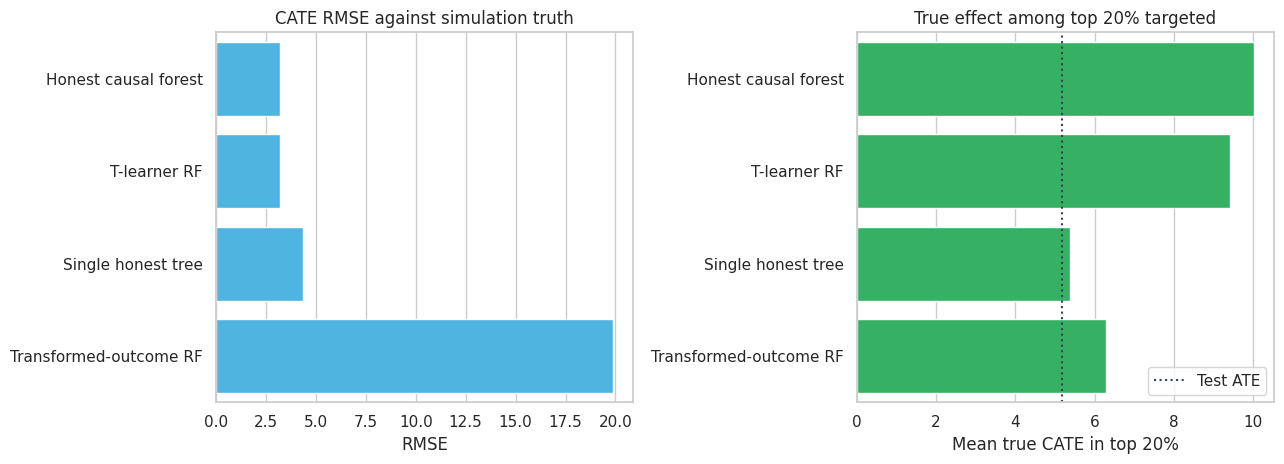

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
plot_metrics = metrics.loc[metrics["model"] != "Oracle true CATE"].copy()

sns.barplot(data=plot_metrics, y="model", x="cate_rmse", color="#38bdf8", ax=axes[0])
axes[0].set_title("CATE RMSE against simulation truth")
axes[0].set_xlabel("RMSE")
axes[0].set_ylabel("")

sns.barplot(data=plot_metrics, y="model", x="true_cate_top20", color="#22c55e", ax=axes[1])
axes[1].axvline(test_scored["true_cate"].mean(), color="#334155", linestyle=":", label="Test ATE")
axes[1].set_title("True effect among top 20% targeted")
axes[1].set_xlabel("Mean true CATE in top 20%")
axes[1].set_ylabel("")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

The honest causal forest improves substantially over a single tree. The T-learner is competitive because the data-generating process has smooth outcome surfaces and both treatment arms are large. The transformed-outcome random forest is useful as a simple baseline, but its target is noisy and it does not separate split discovery from effect estimation.

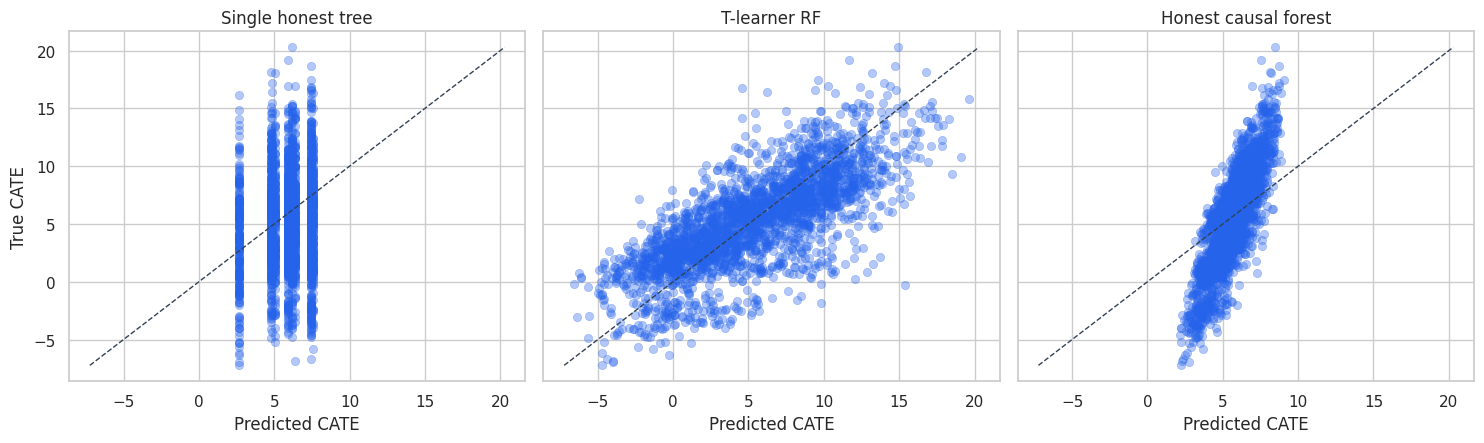

In [13]:
plot_sample = test_scored.sample(2600, random_state=16)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)

for ax, (label, score_col) in zip(
    axes,
    [
        ("Single honest tree", "cate_honest_tree"),
        ("T-learner RF", "cate_t_forest"),
        ("Honest causal forest", "cate_honest_forest"),
    ],
):
    sns.scatterplot(
        data=plot_sample,
        x=score_col,
        y="true_cate",
        alpha=0.35,
        edgecolor=None,
        color="#2563eb",
        ax=ax,
    )
    line_min = min(plot_sample[score_col].min(), plot_sample["true_cate"].min())
    line_max = max(plot_sample[score_col].max(), plot_sample["true_cate"].max())
    ax.plot([line_min, line_max], [line_min, line_max], color="#334155", linestyle="--", linewidth=1)
    ax.set_title(label)
    ax.set_xlabel("Predicted CATE")
    ax.set_ylabel("True CATE")

plt.tight_layout()
plt.show()

The single tree produces coarse predictions because every account in a leaf receives the same effect estimate. The forest smooths over many such partitions and gives a more continuous ranking.

## 9. Decile Validation

In a real randomized experiment, individual treatment effects are unobserved, but we can validate a CATE score by sorting accounts into buckets and estimating treatment-control differences within each bucket.

A useful score should produce higher observed lift in top predicted-CATE buckets.

,decile,n,treatment_share,observed_lift,ci_low,ci_high,predicted_cate_mean,true_cate_mean,tree_sd_mean
0,D1 highest,315,0.508,11.636,8.683,14.589,7.791,11.336,2.506
1,D2,315,0.540,7.544,4.497,10.591,6.880,8.726,2.362
2,D3,315,0.441,5.406,2.520,8.292,6.351,7.515,2.185
3,D4,315,0.470,6.278,3.850,8.705,5.980,6.585,2.108
4,D5,315,0.451,8.082,5.500,10.663,5.672,5.776,2.059
5,D6,315,0.505,3.567,1.046,6.087,5.358,4.565,2.059
6,D7,315,0.489,4.161,1.732,6.591,5.043,3.647,2.138
7,D8,315,0.552,2.501,0.148,4.854,4.679,2.688,2.208
8,D9,315,0.530,1.490,-0.825,3.805,4.250,1.859,2.322
9,D10,315,0.489,-1.938,-4.110,0.234,3.426,-0.839,2.324


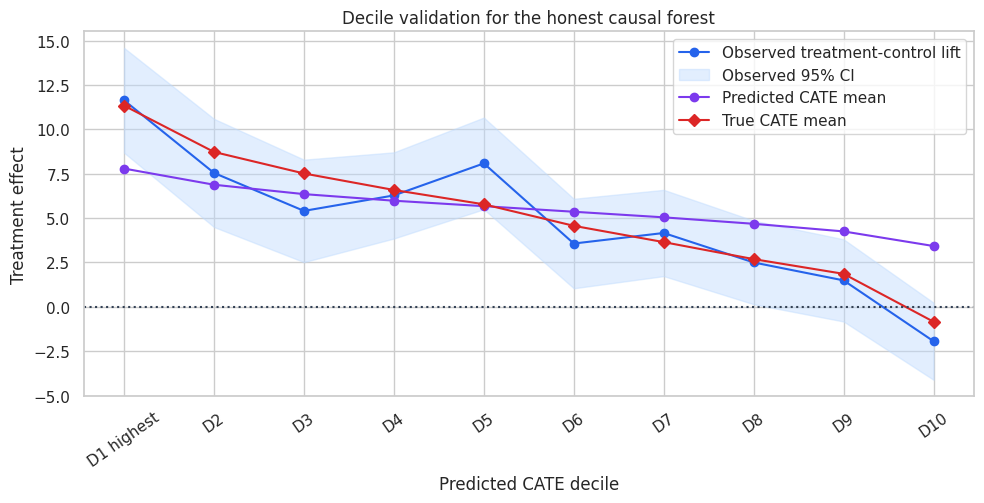

In [14]:
decile_table = decile_validation_table(test_scored, "cate_honest_forest")
display(decile_table.round(3))

fig, ax = plt.subplots(figsize=(10, 5.2))
ax.plot(
    decile_table["decile"],
    decile_table["observed_lift"],
    marker="o",
    color="#2563eb",
    label="Observed treatment-control lift",
)
ax.fill_between(
    np.arange(len(decile_table)),
    decile_table["ci_low"],
    decile_table["ci_high"],
    color="#bfdbfe",
    alpha=0.45,
    label="Observed 95% CI",
)
ax.plot(
    decile_table["decile"],
    decile_table["predicted_cate_mean"],
    marker="o",
    color="#7c3aed",
    label="Predicted CATE mean",
)
ax.plot(
    decile_table["decile"],
    decile_table["true_cate_mean"],
    marker="D",
    color="#dc2626",
    label="True CATE mean",
)
ax.axhline(0, color="#334155", linestyle=":")
ax.set_title("Decile validation for the honest causal forest")
ax.set_xlabel("Predicted CATE decile")
ax.set_ylabel("Treatment effect")
ax.tick_params(axis="x", rotation=35)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

The top predicted deciles show higher lift than the bottom deciles. This is the validation view you can show to a business team. It avoids pretending that individual effects are directly observed.

## 10. Stability and Uncertainty Diagnostics

The forest gives a distribution of tree predictions for each account. This is not the same as a formal confidence interval, but it is useful for model diagnostics.

If two accounts have similar predicted CATE but one has much higher tree-to-tree disagreement, the high-disagreement account should be treated as less stable.

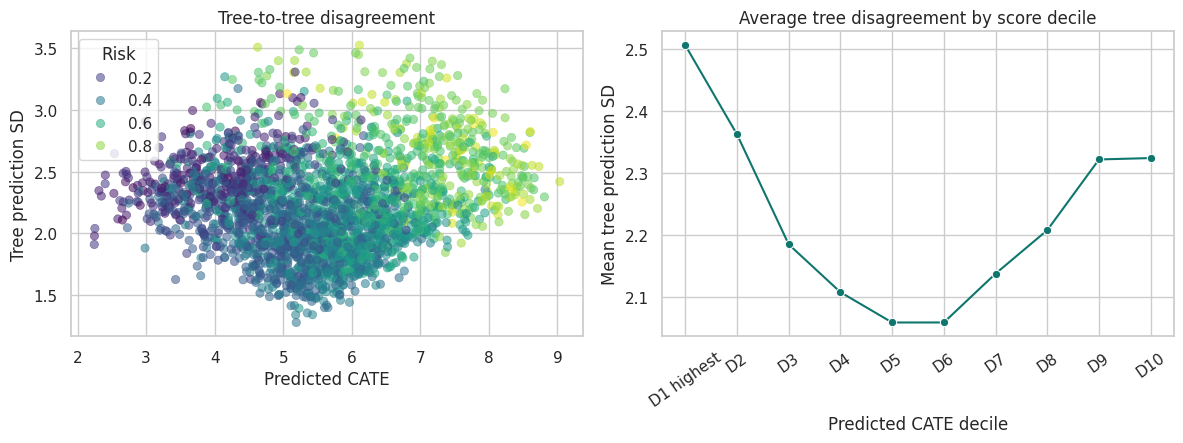

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

sns.scatterplot(
    data=test_scored.sample(2600, random_state=21),
    x="cate_honest_forest",
    y="forest_tree_sd",
    hue="risk_score",
    palette="viridis",
    alpha=0.55,
    edgecolor=None,
    ax=axes[0],
)
axes[0].set_title("Tree-to-tree disagreement")
axes[0].set_xlabel("Predicted CATE")
axes[0].set_ylabel("Tree prediction SD")
axes[0].legend(title="Risk", loc="best")

sns.lineplot(
    data=decile_table,
    x="decile",
    y="tree_sd_mean",
    marker="o",
    color="#0f766e",
    ax=axes[1],
)
axes[1].set_title("Average tree disagreement by score decile")
axes[1].set_xlabel("Predicted CATE decile")
axes[1].set_ylabel("Mean tree prediction SD")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

High uncertainty can come from sparse regions, mixed leaves, weak overlap, or genuinely complex local heterogeneity. In production, uncertainty diagnostics should be combined with randomized holdouts and policy guardrails.

## 11. Feature Importance for Heterogeneity

Feature importance in causal forests is not the same as feature importance in outcome prediction. A feature is important for the forest if it helps find splits with different treatment effects.

We will look at two educational summaries:

- Average split importance across the discovery trees.
- Simulation-only permutation importance: how much CATE RMSE worsens when a feature is shuffled in the test set.

The second measure uses the true CATE and is not available in real projects.

,feature,average_split_importance,rmse_increase_when_permuted
0,risk_score,0.246,0.466
1,engagement_score,0.186,0.414
4,enterprise_plan,0.027,0.150
5,integration_count,0.065,0.068
2,log_account_value,0.240,0.059
6,support_tickets,0.031,0.051
3,tenure_months,0.203,0.020


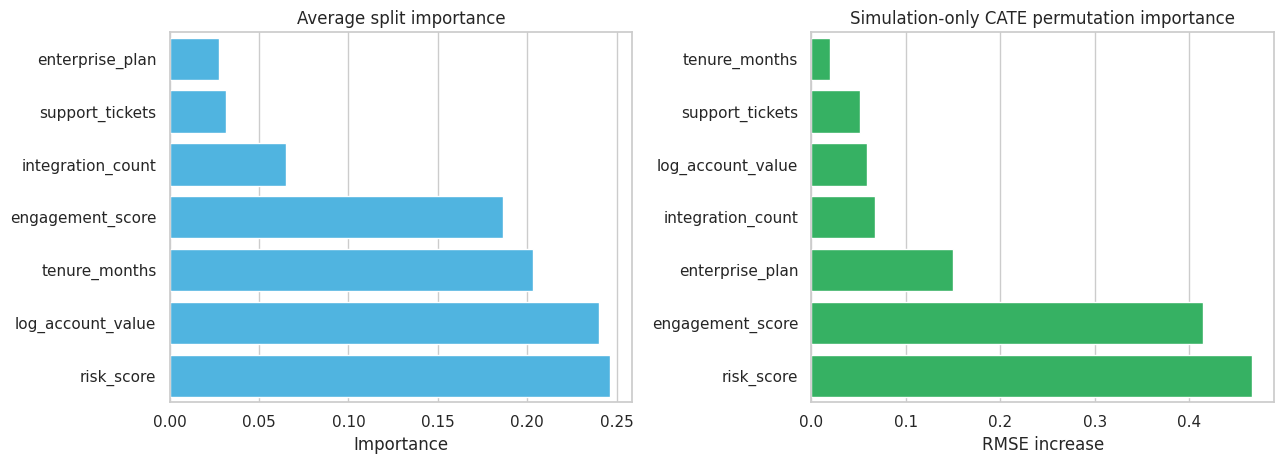

In [16]:
split_importance = pd.DataFrame(
    {
        "feature": feature_cols,
        "average_split_importance": honest_forest["split_importance"],
    }
)

baseline_rmse = np.sqrt(mean_squared_error(test_scored["true_cate"], test_scored["cate_honest_forest"]))
rng = np.random.default_rng(606)
perm_rows = []
for feature in feature_cols:
    permuted = test_scored[feature_cols].copy()
    permuted[feature] = rng.permutation(permuted[feature].to_numpy())
    permuted_pred = predict_honest_forest(honest_forest, permuted)["cate_hat"]
    permuted_rmse = np.sqrt(mean_squared_error(test_scored["true_cate"], permuted_pred))
    perm_rows.append({"feature": feature, "rmse_increase_when_permuted": permuted_rmse - baseline_rmse})

importance_table = split_importance.merge(pd.DataFrame(perm_rows), on="feature").sort_values(
    "rmse_increase_when_permuted",
    ascending=False,
)

display(importance_table.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.barplot(
    data=importance_table.sort_values("average_split_importance", ascending=True),
    y="feature",
    x="average_split_importance",
    color="#38bdf8",
    ax=axes[0],
)
axes[0].set_title("Average split importance")
axes[0].set_xlabel("Importance")
axes[0].set_ylabel("")

sns.barplot(
    data=importance_table.sort_values("rmse_increase_when_permuted", ascending=True),
    y="feature",
    x="rmse_increase_when_permuted",
    color="#22c55e",
    ax=axes[1],
)
axes[1].set_title("Simulation-only CATE permutation importance")
axes[1].set_xlabel("RMSE increase")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

Feature importance should be treated as a screening tool, not as proof of a causal mechanism. The forest can tell us which pre-treatment features help predict treatment-effect variation. Domain knowledge and experimental follow-up are still needed to explain why.

## 12. Targeting Curves

Now convert CATE scores into a targeting decision. Suppose the company has limited customer-success capacity. If it can treat only the top $k$ percent of accounts, how much effect does each scoring rule capture?

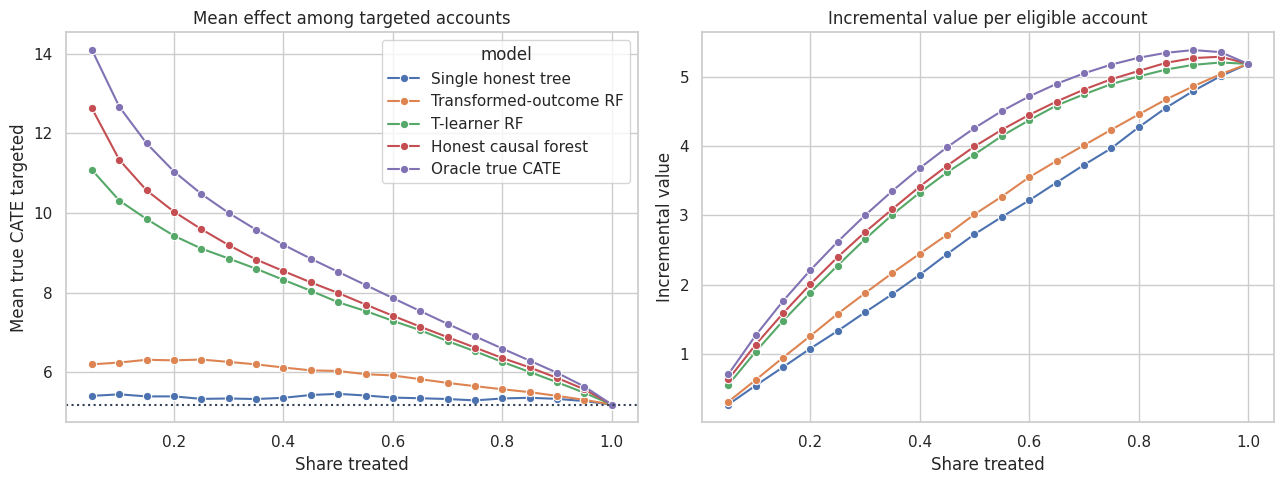

In [17]:
fractions = np.linspace(0.05, 1.00, 20)
curve_rows = []
policy_score_map = {
    "Single honest tree": "cate_honest_tree",
    "Transformed-outcome RF": "cate_transformed_rf",
    "T-learner RF": "cate_t_forest",
    "Honest causal forest": "cate_honest_forest",
    "Oracle true CATE": "oracle_true_cate",
}

for label, score_col in policy_score_map.items():
    for fraction in fractions:
        selected = top_fraction_mask(test_scored, score_col, fraction=fraction)
        targeted = test_scored.loc[selected]
        curve_rows.append(
            {
                "model": label,
                "treatment_share": fraction,
                "mean_true_cate_targeted": targeted["true_cate"].mean(),
                "incremental_value_per_account": fraction * targeted["true_cate"].mean(),
                "negative_cate_share_targeted": (targeted["true_cate"] < 0).mean(),
            }
        )

policy_curves = pd.DataFrame(curve_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.lineplot(
    data=policy_curves,
    x="treatment_share",
    y="mean_true_cate_targeted",
    hue="model",
    marker="o",
    ax=axes[0],
)
axes[0].axhline(test_scored["true_cate"].mean(), color="#334155", linestyle=":", label="Treat-all average")
axes[0].set_title("Mean effect among targeted accounts")
axes[0].set_xlabel("Share treated")
axes[0].set_ylabel("Mean true CATE targeted")

sns.lineplot(
    data=policy_curves,
    x="treatment_share",
    y="incremental_value_per_account",
    hue="model",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Incremental value per eligible account")
axes[1].set_xlabel("Share treated")
axes[1].set_ylabel("Incremental value")
axes[1].legend_.remove()

plt.tight_layout()
plt.show()

The causal forest is useful when treatment capacity is limited because it ranks accounts by estimated incremental value. If the company can treat everyone, the ranking matters less. If the company can treat only 10% to 30%, the ranking can be the difference between a high-value program and wasted capacity.

## 13. Practical Notes for Production

In production, use a mature implementation when possible. The simplified implementation here omits many details that matter for inference and reliability.

Practical checks:

- Verify treatment assignment or adjust for confounding with propensity and outcome nuisance models.
- Use only pre-treatment features.
- Check overlap before trusting local effects.
- Validate ranked groups with randomized holdout traffic.
- Report bucket-level effects, not only individual CATE scores.
- Monitor model drift and treatment saturation over time.
- Treat feature importance as heterogeneity screening, not mechanistic proof.
- Keep an exploration policy so future data still contain treatment and control variation across the score range.

Causal forests are powerful because they search for heterogeneity flexibly. That same flexibility makes validation essential.

In [18]:
readout = pd.DataFrame(
    {
        "question": [
            "What did the forest learn?",
            "Who should be targeted first?",
            "What should stakeholders see?",
            "What is the main caution?",
            "What should happen after deployment?",
        ],
        "answer": [
            "Treatment effects are highest for accounts with risk and room for engagement improvement.",
            "Prioritize the top predicted-CATE deciles, subject to capacity and guardrails.",
            "Show decile lift, targeting curves, and uncertainty/stability diagnostics.",
            "Do not interpret individual CATEs as observed facts; validate by groups.",
            "Keep randomized holdouts and monitor score calibration over time.",
        ],
    }
)

display(readout)

,question,answer
0,What did the forest learn?,Treatment effects are highest for accounts wit...
1,Who should be targeted first?,"Prioritize the top predicted-CATE deciles, sub..."
2,What should stakeholders see?,"Show decile lift, targeting curves, and uncert..."
3,What is the main caution?,Do not interpret individual CATEs as observed ...
4,What should happen after deployment?,Keep randomized holdouts and monitor score cal...


## Key Takeaways

- A causal forest estimates treatment effects, not just outcomes.
- Honest trees separate split discovery from treatment-effect estimation.
- A forest averages many local treatment-control contrasts, reducing single-tree instability.
- Forest predictions can be understood as adaptive neighborhood estimates.
- Tree-to-tree dispersion is a useful stability diagnostic but not a formal confidence interval.
- Decile validation and policy curves are more useful for business decisions than individual CATE claims.
- Mature causal-forest implementations add optimized splitting, nuisance adjustment, and inference tools beyond this educational version.

## References

Athey, S., & Imbens, G. W. (2016). Recursive partitioning for heterogeneous causal effects. *Proceedings of the National Academy of Sciences, 113*(27), 7353-7360. https://doi.org/10.1073/pnas.1510489113

Athey, S., Tibshirani, J., & Wager, S. (2019). Generalized random forests. *The Annals of Statistics, 47*(2), 1148-1178. https://doi.org/10.1214/18-AOS1709

Breiman, L. (2001). Random forests. *Machine Learning, 45*(1), 5-32. https://doi.org/10.1023/A:1010933404324

Nie, X., & Wager, S. (2020). Quasi-oracle estimation of heterogeneous treatment effects. *Biometrika, 108*(2), 299-319. https://doi.org/10.1093/biomet/asaa076

Wager, S., & Athey, S. (2018). Estimation and inference of heterogeneous treatment effects using random forests. *Journal of the American Statistical Association, 113*(523), 1228-1242. https://doi.org/10.1080/01621459.2017.1319839